## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA

import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

In [2]:
# # 读取数据
# data_path = '/home/lqr/CLIMA/code/data/'
# sc = np.load(data_path + '/sc_data.npz')
# st = np.load(data_path + '/st_data.npz')

# # sc_data = [sc[key] for key in sc.files]
# # st_data = [st[key] for key in st.files]
# sc_data = [sc['sc_gene'], sc['sc_atac']]

In [3]:
from os.path import join
import pandas as pd

data_path = '/home/lqr/CLIMA/datasets/new_simu/'
# data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_counts.csv'), index_col=0)
data1 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_Gene_normalized.csv'), index_col=0)
# data3 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_counts.csv'), index_col=0)
data2 = pd.read_csv(join(data_path, 'GSE140203_mouse_brain_PeakonGene_normalized.csv'), index_col=0)



In [4]:
# 转换成numpy数组
gene = data1.T.values
peak = data2.T.values
gene_peak = gene + peak

## Generate simulation data


Simulation parameters

In [5]:
latent_dim = 100
# num_cluster = 10
sample_size = 1000



Use simulation tool to generate multi-modality data

## Analyses based on single modality

Learn features from single modality

In [6]:
view_gene_feature = PCA(n_components=latent_dim).fit_transform(gene)
view_peak_feature = PCA(n_components=latent_dim).fit_transform(peak)
view_c_feature = PCA(n_components=latent_dim).fit_transform(gene_peak)

In [7]:
print(f"gene.shape: {gene.shape}")
print(f"peak.shape: {peak.shape}")
print(f"view_gene_feature.shape: {view_gene_feature.shape}")
print(f"view_peak_feature.shape: {view_peak_feature.shape}")

gene.shape: (3293, 21127)
peak.shape: (3293, 21127)
view_gene_feature.shape: (3293, 100)
view_peak_feature.shape: (3293, 100)


Perform clustering using PhenoGraph

In [8]:
view_a_label, _, _ = phenograph.cluster(view_gene_feature)
view_b_label, _, _ = phenograph.cluster(view_peak_feature)
view_c_label, _, _ = phenograph.cluster(view_c_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10197901725769043 seconds
Jaccard graph constructed in 0.5068988800048828 seconds
Wrote graph to binary file in 0.013900995254516602 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.888871
After 15 runs, maximum modularity is Q = 0.890175
Louvain completed 35 runs in 1.8582570552825928 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.8461415767669678 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08128094673156738 seconds
Jaccard graph constructed in 0.4461374282836914 seconds
Wrote graph to binary file in 0.016427993774414062 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.285532
After 3 runs, maximum modularity is Q = 0.28778
Louvain completed 23 runs in 1.4603424072265625 seconds
Sorting communities by size, please wait

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [9]:
outputs = muse.dual_muse_fit_predict(
    [gene, peak],
    [gene_peak],
    [view_a_label, view_b_label],
    [view_c_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=0,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
logits: tensor([[ 0.0757,  1.0568,  0.7883,  ...,  0.9043, -1.4633, -0.0123],
        [-1.0260,  0.3821,  0.0044,  ...,  0.1330,  0.4907,  1.5091],
        [ 0.5482,  0.5128,  0.8499,  ..., -1.3590,  0.0857,  0.7612],
        ...,
        [ 0.2325, -0.2747, -0.1129,  ..., -0.9135, -0.8762,  0.6406],
        [ 2.4165,  2.0492,  1.6587,  ..., -1.2570,  0.9911,  1.0897],
        [ 0.2607,  1.0848,  0.9720,  ..., -0.5140,  0.3548,  1.8644]],
       device='cuda:0', grad_fn=<DivBackward0>)


NameError: name 'quit' is not defined

In [10]:
latent_sc = (outputs[0])
latent_st = (outputs[1])
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (3293, 100)
latent_st: (3293, 100)
reconstruct_sc: (2, 3293, 21127)
reconstruct_st: (1, 3293, 21127)
encoded_sc: (2, 3293, 128)
encoded_st: (1, 3293, 128)


## Perform clustering
PhenoGraph clustering

In [11]:
latent_label_sc, _, _ = phenograph.cluster(latent_sc)
latent_label_st, _, _ = phenograph.cluster(latent_st)

label_true = view_c_label

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0721735954284668 seconds
Jaccard graph constructed in 0.5579831600189209 seconds
Wrote graph to binary file in 0.017688512802124023 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.136429
Louvain completed 21 runs in 1.3501307964324951 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.4914422035217285 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07879042625427246 seconds
Jaccard graph constructed in 0.5861423015594482 seconds
Wrote graph to binary file in 0.01531362533569336 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.901415
Louvain completed 21 runs in 1.402730941772461 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.573049783706665 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

X_embedded: (3293, 2)
label_true: (3293,)


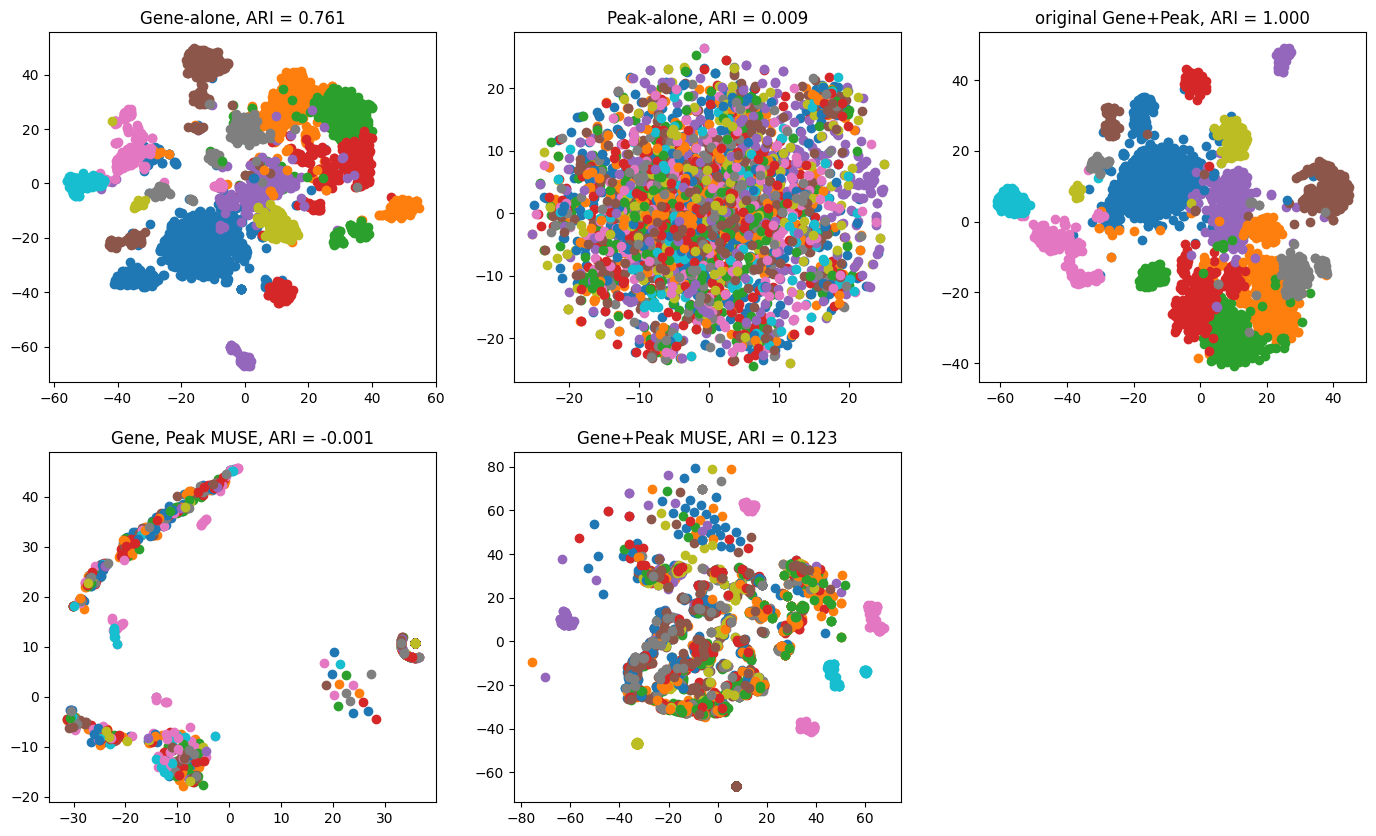

In [12]:
from matplotlib import gridspec

plt.figure(figsize=(17, 10))
gs = gridspec.GridSpec(2, 3)
# Gene-alone
plt.subplot(gs[0, 0])
X_embedded = TSNE(n_components=2).fit_transform(view_gene_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Gene-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

# Peak-alone
plt.subplot(gs[0, 1])
X_embedded = TSNE(n_components=2).fit_transform(view_peak_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Peak-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

# Gene, Peak MUSE(latent sc)
plt.subplot(gs[1, 0])
X_embedded = TSNE(n_components=2).fit_transform(latent_sc)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Gene, Peak MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, latent_label_sc))

# Peak+Gene MUSE(latent st)
plt.subplot(gs[1, 1])
X_embedded = TSNE(n_components=2).fit_transform(latent_st)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Gene+Peak MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, latent_label_st))

# original Gene+Peak
plt.subplot(gs[0, 2])
X_embedded = TSNE(n_components=2).fit_transform(view_c_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('original Gene+Peak, ARI = %01.3f' % adjusted_rand_score(label_true, view_c_label))
plt.show()


In [13]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(latent_label_sc, latent_label_st))

[gene, peak] and [gene+peak] ARI:  0.009807758368713873


**************************************************
S: torch.Size([3293, 100, 1])
G: torch.Size([3293, 100, 1])


 22%|██▏       | 111/500 [00:00<00:01, 368.72it/s]

Epoch 50: Loss -2108.5537109375
Epoch 100: Loss -2259.62841796875


 37%|███▋      | 187/500 [00:00<00:00, 372.07it/s]

Epoch 150: Loss -2326.888671875
Epoch 200: Loss -2360.14404296875


...

Epoch 250: Loss -2374.1640625
Epoch 300: Loss -2383.5380859375


 83%|████████▎ | 417/500 [00:01<00:00, 375.04it/s]

Epoch 350: Loss -2385.16943359375
Epoch 400: Loss -2397.9248046875


100%|██████████| 500/500 [00:01<00:00, 374.20it/s]

Epoch 450: Loss -2405.345458984375
Epoch 500: Loss -2410.75732421875
[[ 0.04268389  1.0715202  -0.29789028 ...  3.2112794   1.4730034
   0.6424545 ]
 [ 0.7253513   0.8959572  -0.54977167 ... -0.51134485 -0.7316911
   0.12693685]
 [ 0.9605928   0.46628603 -0.61700803 ... -0.33964184 -0.22071053
   2.8673043 ]
 ...
 [ 1.2550985  -0.1862297   0.4529942  ... -0.1916253   0.51839024
  -1.6095228 ]
 [ 1.5317978   0.48159423  0.28810346 ... -0.36111984  0.0942862
  -0.7475235 ]
 [ 0.61911064  0.12066682 -2.2901447  ... -0.5915202   0.3214792
  -0.42105302]]


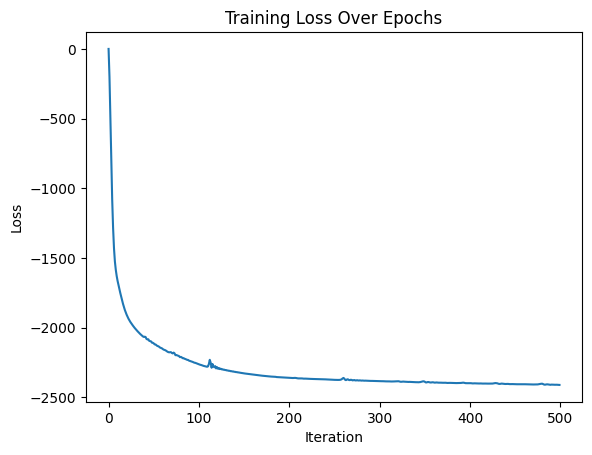

In [34]:
from sim_tangram.train_tangram import read_csv_and_run_tangram
import torch

# tangram
tangram_sim, _ = read_csv_and_run_tangram(
    # [torch.tensor(latent_sc, device='cuda:0')],
    # [torch.tensor(latent_st, device='cuda:0')],
    [torch.tensor(view_c_feature, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=50,
    spotwise=True,
    genewise=False,
)

In [35]:
mapping = tangram_sim.argmax(axis=1)
for i in range(len(mapping)):
    if i < 50:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {mapping[i]:4d}", end="\t")


 0: 1608	 1: 2583	 2: 2353	 3: 3096	 4: 2923	
 5: 1950	 6: 2925	 7: 3064	 8: 2560	 9: 2380	
10: 3064	11:  223	12: 2703	13: 1195	14: 1950	
15: 2353	16:  682	17: 2853	18: 2440	19: 3117	
20:  801	21: 2925	22: 2151	23: 2925	24: 1408	
25:  682	26: 2141	27: 1195	28: 2550	29: 2925	
30: 2975	31:  682	32: 2754	33: 2595	34: 3271	
35: 2219	36: 2255	37:  567	38:  194	39:  795	
40:  665	41: 2654	42: 3034	43: 1195	44: 2171	
45: 2925	46: 1195	47:  596	48: 1897	49: 2925	

In [36]:
sample_size = tangram_sim.shape[0]
gt = np.array(range(sample_size))
acc = np.sum(mapping == gt) / sample_size
print("accuracy:", acc)

accuracy: 0.0006073489219556636
